<a href="https://colab.research.google.com/github/JoaoAntoni07/estudo-catijr/blob/main/semana-04/semana04_aulas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semana 04

## Coleta de dados

### Lendo dados com Pandas

In [ ]:
import pandas as pd

# vou usar um arquivo.csv disponibilizado pelo colab'
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
# shape - quantas linhas e colunas
df.shape

(17000, 9)

In [ ]:
# columns - mostra o nome das colunas
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [ ]:
# info() - mostra os tipos de dados e os valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


In [ ]:
# describe() - mostra estatísticas básicas sobre as colunas
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [ ]:
# problemas comuns
# separador errado, solução: "sep=..." ... = separador desejado
# problema de codificação, solução: encoding"latin1"
# cabeçalho na linha errada, solução: header = n - n é a linha desejada

### Lendo dados de URL e API

In [ ]:
# lendo um csv de uma url
# exemplo: base pública do IBGE
csv_url = "https://people.sc.fsu.edu/~jburkardt/data/csv/airtravel.csv"
df_url = pd.read_csv(csv_url)
df_url.head()

,Month,"""1958""","""1959""","""1960"""
0,JAN,340,360,417
1,FEB,318,342,391
2,MAR,362,406,419
3,APR,348,396,461
4,MAY,363,420,472


In [ ]:
# lendo dados de uma API com requests
import requests

url = "https://catfact.ninja/fact"
resposta = requests.get(url)
dados = resposta.json()
print(dados)

{'fact': 'A form of AIDS exists in cats.', 'length': 30}


In [ ]:
# transformando resposta json em dataframe
df_api = pd.DataFrame([dados])
df_api

,fact,length
0,A form of AIDS exists in cats.,30


In [ ]:
# nem toda api retorna uma tabela pronta
# as vezes é preciso navegar dentro de estruturas json
# usar .json() para explorar a estrutura primeiro

### Lendo dados via Google Drive

In [ ]:
# conectar o colab ao drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# lendo arquivo com pandas
caminho = '/content/drive/MyDrive/customers.csv'
df = pd.read_csv(caminho)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### Usando SQLite

In [ ]:
# carregar o csv
caminho = '/content/drive/MyDrive/customers.csv'
df = pd.read_csv(caminho)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# enviando dataframe para um banco SQLite
import sqlite3

# criar banco em memória
conn = sqlite3.connect(':memory:')

# enviar o dataframe
df.to_sql('costumers', conn, index=False, if_exists='replace')

200

In [ ]:
# consultando tabela usando Pandas
df_sq1 = pd.read_sql_query('SELECT Age FROM costumers', conn)
df_sq1.head()

,Age
0,19
1,21
2,20
3,23
4,31


In [ ]:
# filtro em consultas
df_sq2 = pd.read_sql_query('SELECT * FROM costumers WHERE Age > 24', conn)
df_sq2.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,5,Female,31,17,40
1,7,Female,35,18,6
2,9,Male,64,19,3
3,10,Female,30,19,72
4,11,Male,67,19,14


### Fazendo Queries

In [ ]:
# carregar o csv
df = pd.read_csv('/content/drive/MyDrive/customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
# enviar os dados para o SQLite
import sqlite3

conn = sqlite3.connect(':memory:')

df.to_sql('costumers', conn, index=False, if_exists='replace')

200

In [ ]:
# usando SQL no pandas

# escolher colunas
df_sq1 = pd.read_sql_query('SELECT Gender, Age FROM costumers', conn)
df_sq1.head()

,Gender,Age
0,Male,19
1,Male,21
2,Female,20
3,Female,23
4,Female,31


In [ ]:
# filtrar linhas
df_sq2 = pd.read_sql_query('SELECT * FROM costumers WHERE Age > 35', conn)
df_sq2.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,9,Male,64,19,3
1,11,Male,67,19,14
2,13,Female,58,20,15
3,15,Male,37,20,13
4,19,Male,52,23,29


In [ ]:
# limit - limitar o número de resultados
pd.read_sql('SELECT * FROM costumers LIMIT 3', conn)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [ ]:
# combinações lógicas
df = pd.read_sql_query("SELECT * FROM costumers WHERE Gender = 'Male' AND Age < 45", conn)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,15,Male,37,20,13
3,16,Male,22,20,79
4,18,Male,20,21,66


In [ ]:
df2 = pd.read_sql_query("SELECT * FROM costumers WHERE NOT Gender = 'Male'", conn)
df2.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,3,Female,20,16,6
1,4,Female,23,16,77
2,5,Female,31,17,40
3,6,Female,22,17,76
4,7,Female,35,18,6


In [ ]:
# order by
df_orfder_by = pd.read_sql_query("SELECT Age FROM costumers ORDER BY Gender DESC", conn)
df_orfder_by.head()

,Age
0,19
1,21
2,64
3,67
4,37


In [ ]:
# as
df_as = pd.read_sql_query("SELECT Age AS Idade FROM costumers", conn)
df_as.head()

,Idade
0,19
1,21
2,20
3,23
4,31


In [ ]:
# distinct
df_distinct = pd.read_sql_query("SELECT DISTINCT Age FROM costumers", conn)

In [ ]:
# in/between/like
# SELECT * FROM ... WHERE ... IN()
# SELECT * FROM ... WHERE ... BETWEEN ... AND ...
# SELECT * FROM ... WHERE ... LIKE '...'

#### Desafio Pŕatico
- Implemente, do zero, um sistema de análise de dados de vendas em Python, utilizando um arquivo CSV. O sistema deve carregar os dados, exibir informações básicas, realizar consultas específicas e, opcionalmente, gerar visualizações e relatórios.

In [6]:
import pandas as pd
import sqlite3

In [7]:
# carregando o banco de dados e exibindo as primeiras linhas
caminho = '/content/drive/MyDrive/airtravel.csv'
df = pd.read_csv(caminho, skipinitialspace=True)
df.head()

,Month,1958,1959,1960
0,JAN,340,360,417
1,FEB,318,342,391
2,MAR,362,406,419
3,APR,348,396,461
4,MAY,363,420,472


In [8]:
# resumo técnico
print(df.shape)
print(df.info())
print(df.columns)

(12, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   12 non-null     object
 1   1958    12 non-null     int64 
 2   1959    12 non-null     int64 
 3   1960    12 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 516.0+ bytes
None
Index(['Month', '1958', '1959', '1960'], dtype='object')


In [9]:
# resumo estático
# média
media_58s = df['1958'].mean()
media_59s = df['1959'].mean()
media_60s = df['1960'].mean()
print(f"MÉDIAS DOS ANOS 58, 59 E 60: {media_58s:.2f}, {media_59s:.2f} e {media_60s:.2f}")
media_total = (media_58s + media_59s + media_60s) / 3
print(f"A MÉDIA GERAL É: {media_total:.2f}")
# valor máximo
max_58s = df['1958'].max()
max_59s = df['1959'].max()
max_60s = df['1960'].max()
print(f"VALORES MÁXIMOS DOS ANOS 58, 59 E 60: {max_58s}, {max_59s} e {max_60s}")
# valor mínimo
min_58s = df['1958'].min()
min_59s = df['1959'].min()
min_60s = df['1960'].min()
print(f"VALORES MÍNIMOS DOS ANOS 58, 59 E 60: {min_58s}, {min_59s} e {min_60s}")

MÉDIAS DOS ANOS 58, 59 E 60: 381.00, 428.33 e 476.17
A MÉDIA GERAL É: 428.50
VALORES MÁXIMOS DOS ANOS 58, 59 E 60: 505, 559 e 622
VALORES MÍNIMOS DOS ANOS 58, 59 E 60: 310, 342 e 390


In [10]:
# consultas específicas usando SQL
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('airtravel', conn, index=False, if_exists='replace')

# consultando somente os meses que tiveram mais de 400 voos em 1958
df_busca1 = pd.read_sql_query('SELECT Month FROM airtravel WHERE "1958" > 400', conn)
df_busca1.head()

,Month
0,JUN
1,JUL
2,AUG
3,SEP


In [14]:
# consultando total de viagens de 1958
df_total_viagens_58 = pd.read_sql_query('SELECT SUM("1958") AS Total_viagens_1958 FROM airtravel', conn)
df_total_viagens_58

,Total_viagens_1958
0,4572


In [13]:
# consultando total de viagens de 1959
df_total_viagens_59 = pd.read_sql_query('SELECT SUM("1959") AS Total_viagens_1959 FROM airtravel', conn)
df_total_viagens_59

,Total_viagens_1959
0,5140


In [18]:
# consultando total de viagens de 1960
df_total_viagens_60 = pd.read_sql_query('SELECT SUM("1960") AS Total_viagens_1960 FROM airtravel', conn)
df_total_viagens_60

,Total_viagens_1960
0,5714


In [23]:
# total de viagens
query_total_viagens = '''
    SELECT SUM("1958") + SUM("1959") + SUM("1960")
    AS Soma_total
    FROM airtravel
'''
df_total_viagens_geral = pd.read_sql_query(query_total_viagens, conn)
df_total_viagens_geral

,Soma_total
0,15426


## Tratando dados

### Quartis

In [29]:
import pandas as pd

# carregar os dados
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv'
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [32]:
# calculando quartis - .quantile()
quartis = df['total_bill'].quantile([0.25, 0.5, 0.75])
print('Quartis: ')
print(quartis)

Quartis: 
0.25    13.3475
0.50    17.7950
0.75    24.1275
Name: total_bill, dtype: float64


In [33]:
df['total_bill'].describe()

,total_bill
count,244.000000
mean,19.785943
std,8.902412
min,3.070000
25%,13.347500
50%,17.795000
75%,24.127500
max,50.810000


In [38]:
# usando qcut
df['segmento'] = pd.qcut(df['total_bill'], q=4, labels=['baixo', 'médo-baixo', 'médio-alto', 'alto'])
df[['total_bill', 'segmento']].head()

,total_bill,segmento
0,16.99,médo-baixo
1,10.34,baixo
2,21.01,médio-alto
3,23.68,médio-alto
4,24.59,alto


In [37]:
# usando quartis na coluna tips
quartis_tips = df['tip'].quantile([0.25, 0.5, 0.75])
print('Quartis das corjetas: ')
print(quartis_tips)

Quartis das corjetas: 
0.25    2.0000
0.50    2.9000
0.75    3.5625
Name: tip, dtype: float64


In [39]:
# usando qcut
df['segmento'] = pd.qcut(df['total_bill'], q=4, labels=['baixo', 'médo-baixo', 'médio-alto', 'alto'])
df[['tip', 'segmento']].head()

,tip,segmento
0,1.01,médo-baixo
1,1.66,baixo
2,3.50,médio-alto
3,3.31,médio-alto
4,3.61,alto


### Vizualizando variáveis com histogramas e boxplots

In [2]:
# criando dados simulados
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# dados normais
dados_normais = np.random.normal(loc=50, scale=10, size=1000)

# dados com outliers
dados_com_outliers = np.append(dados_normais, [150, 160, 170])

#definindo o número de amostras
n = 1000

# distribuição normal padrão
normal_data = np.random.normal(loc=1, scale=1, size=n)

#distribuição com cauda longa
long_tail_data = np.random.lognormal(mean=1, sigma=1, size=n)

#criação do dataframe
df = pd.DataFrame({
    'normal' : normal_data,
    'long_tail' : long_tail_data
})

df.head()

,normal,long_tail
0,2.399355,1.383784
1,1.924634,2.352506
2,1.059630,1.230696
3,0.353063,1.997784
4,1.698223,0.409174


<function matplotlib.pyplot.show(close=None, block=None)>

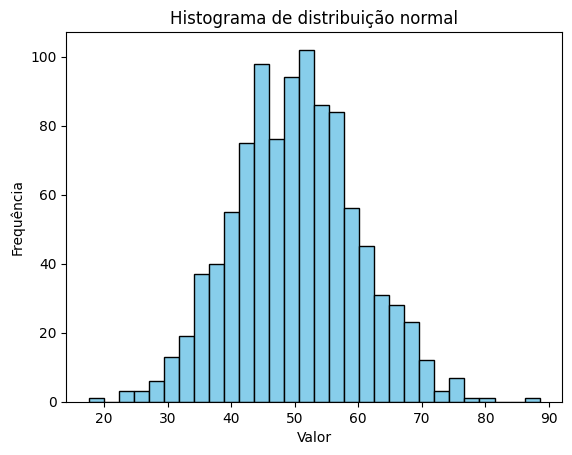

In [43]:
# vizualizando com histogramas - dados normais
plt.hist(dados_normais, bins=30, color='skyblue', edgecolor='black')
plt.title('Histograma de distribuição normal')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

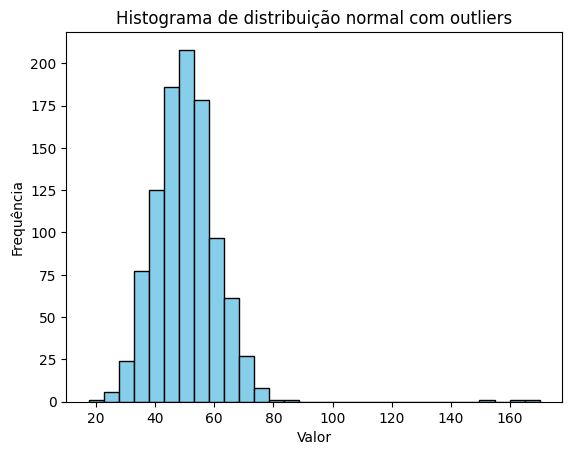

In [44]:
# vizualizando com histogramas - dados com outleirs
plt.hist(dados_com_outliers, bins=30, color='skyblue', edgecolor='black')
plt.title('Histograma de distribuição normal com outliers')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show

In [46]:
# comparando média e mediana com/sem outliers
print(f"MÉDIA NORMAL: {dados_normais.mean()}")
print(f"MÉDIA COM OUTLIERS: {dados_com_outliers.mean()}")
print(f"MEDIANA NORMAL: {np.median(dados_normais)}")
print(f"MEDIANA COM OUTLIERS: {np.median(dados_com_outliers)}")

MÉDIA NORMAL: 50.193320558223256
MÉDIA COM OUTLIERS: 50.521755292346214
MEDIANA NORMAL: 50.25300612234888
MEDIANA COM OUTLIERS: 50.26885838994531


<function matplotlib.pyplot.show(close=None, block=None)>

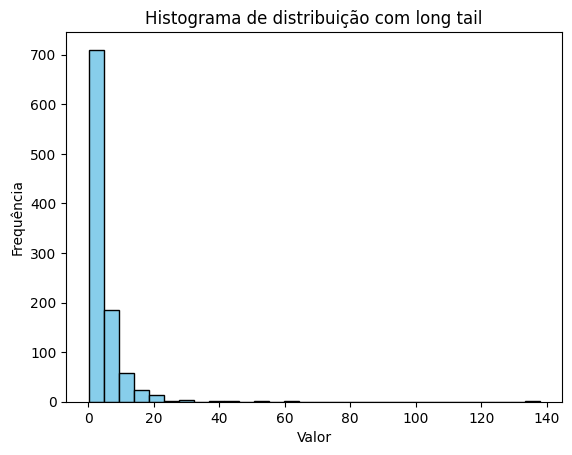

In [47]:
# mostrando gráfico long tail
# vizualizando com histogramas - dados normais
plt.hist(long_tail_data, bins=30, color='skyblue', edgecolor='black')
plt.title('Histograma de distribuição com long tail')
plt.xlabel('Valor')
plt.ylabel('Frequência')
plt.show

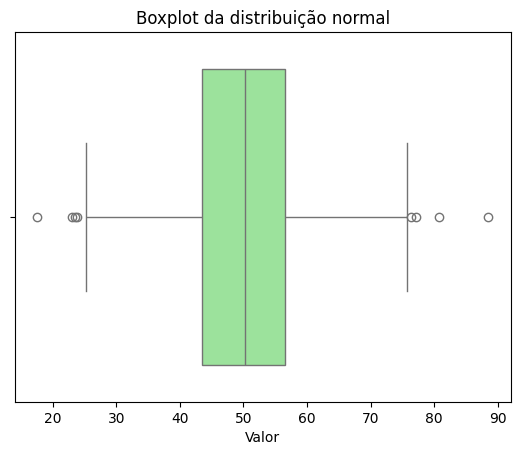

In [49]:
# lendo um boxplot
import seaborn as sns

sns.boxplot(x=dados_normais, color='lightgreen')
plt.title('Boxplot da distribuição normal')
plt.xlabel('Valor')
plt.show()

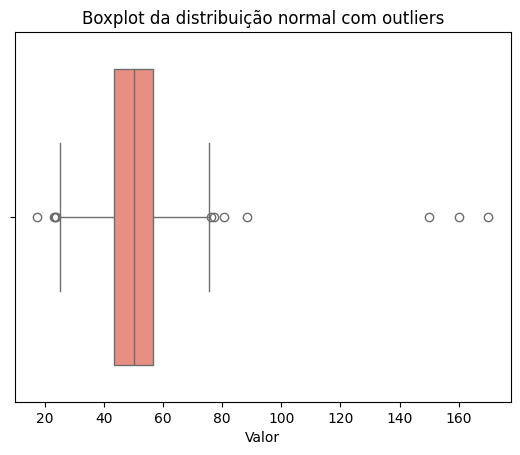

In [51]:
# boxplot com outliers
sns.boxplot(x=dados_com_outliers, color='salmon')
plt.title('Boxplot da distribuição normal com outliers')
plt.xlabel('Valor')
plt.show()

Text(0.5, 1.0, 'Com outliers')

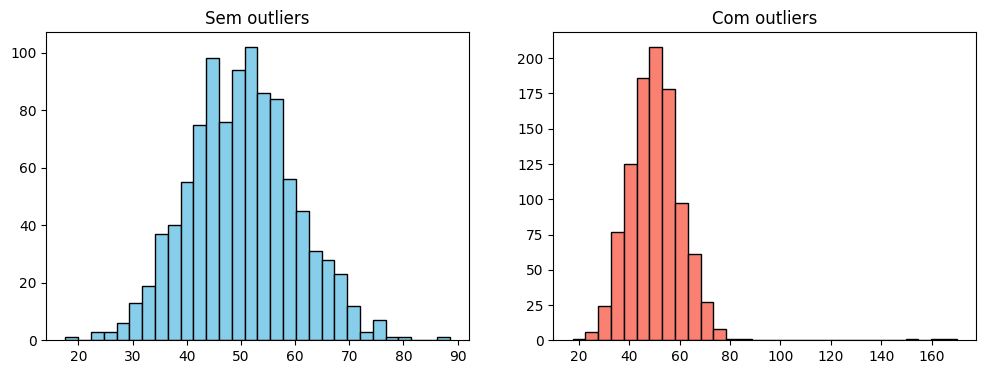

In [3]:
from IPython.core.pylabtools import figsize
# comparando com e sem outliers
plt.figure(figsize(12, 4))

plt.subplot(1, 2, 1)
plt.hist(dados_normais, bins=30, color='skyblue', edgecolor='black')
plt.title('Sem outliers')

plt.subplot(1, 2, 2)
plt.hist(dados_com_outliers, bins=30, color='salmon', edgecolor='black')
plt.title('Com outliers')


### Visualizando relações com Scatterplots e Heatmaps

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# criar variáveis com diferentes padrões
tamanho = 100
idade = np.random.randint(18, 60, size=tamanho)
salario = idade * 500 + np.random.normal(0, 5000, size=tamanho)
horas_sono = np.random.normal(7, 1, size=tamanho)
horas_estudo = np.random.normal(2, 0.5, size=tamanho)
filhos = np.random.randint(0, 4, size=tamanho)

df = pd.DataFrame({
    'idade' : idade,
    'salario' : salario,
    'sono' : horas_sono,
    'estudo' : horas_estudo,
    'filhos' : filhos
})

df.head()

,idade,salario,sono,estudo,filhos
0,56,27158.974560,6.853055,2.043283,1
1,46,28823.843228,7.180623,1.703559,3
2,32,14771.261563,7.964811,1.659998,1
3,25,8651.661132,5.935169,1.868297,1
4,38,25060.861711,7.108712,1.859673,3


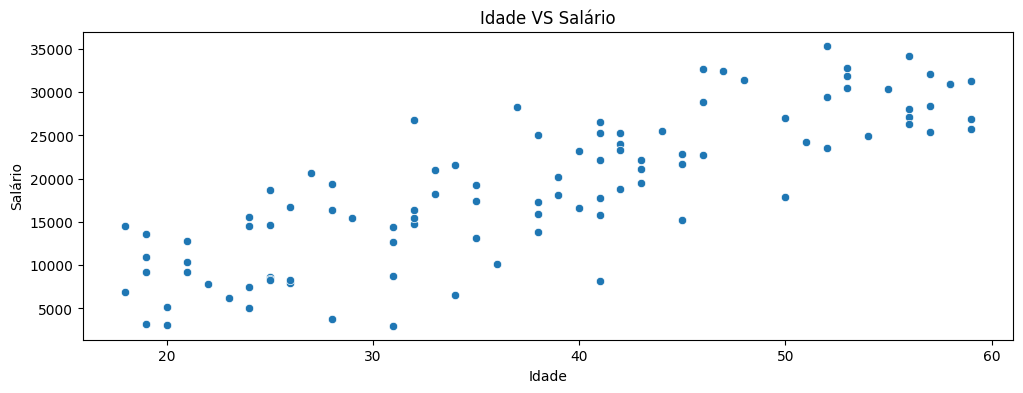

In [8]:
# scatterplot - explorando relações entre duas variáveis
sns.scatterplot(data=df, x='idade', y='salario')
plt.title('Idade VS Salário')
plt.xlabel('Idade')
plt.ylabel('Salário')
plt.show()

In [9]:
# heatmap - correlação entre variáveis
df.corr()

,idade,salario,sono,estudo,filhos
idade,1.000000,0.826410,-0.066733,-0.050742,0.036300
salario,0.826410,1.000000,-0.052534,-0.068463,0.009942
sono,-0.066733,-0.052534,1.000000,-0.093312,0.061578
estudo,-0.050742,-0.068463,-0.093312,1.000000,-0.015848
filhos,0.036300,0.009942,0.061578,-0.015848,1.000000


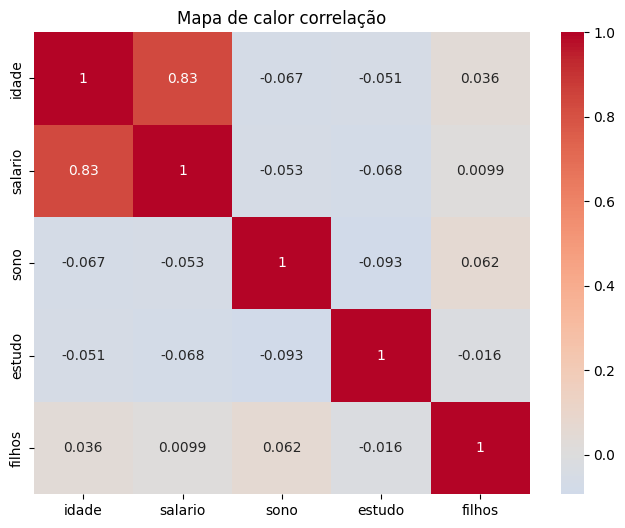

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', center=0)
plt.title('Mapa de calor correlação')
plt.show()

### Detectando e tratando outliers

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# simulando uma base com outliers
np.random.seed(0)
df = pd.DataFrame({
    'gastos' : np.append(np.random.normal(500, 50, 100), [1200, 1300, 1500])
})
df.head()

,gastos
0,588.202617
1,520.007860
2,548.936899
3,612.044660
4,593.377900


In [13]:
# detectando iqr - intervalo interquartil
Q1 = df['gastos'].quantile(0.25)
Q3 = df['gastos'].quantile(0.75)
IQR = Q1 - Q3

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_iqr = df[(df['gastos'] < limite_inferior) | (df['gastos'] > limite_superior)]
print(f"Total de outliers: {len(outliers_iqr)}")
outliers_iqr

Total de outliers: 103


,gastos
0,588.202617
1,520.007860
2,548.936899
3,612.044660
4,593.377900
...,...
98,506.345605
99,520.099468
100,1200.000000
101,1300.000000


In [14]:
# detectando com z-score
from scipy.stats import zscore

z_score = zscore(df['gastos'])
outliers_z = df[np.abs(z_score) > 3]
print(f"Total de outliers com Z-score: {len(outliers_z)}")
outliers_z

Total de outliers com Z-score: 3


,gastos
100,1200.0
101,1300.0
102,1500.0


In [17]:
# como tratar outliers
# exclusão com iqr
df_excluido = df[(df['gastos'] <= limite_inferior) & (df['gastos'] >= limite_superior)]
print(f"Base após exclusão: {df_excluido.shape[0]} registros")

Base após exclusão: 84 registros


In [ ]:
# substituir por outro outliers
